# Logistic regression, built up on the MOT data

Five short steps, from one feature to the deployed model:

1. One feature, by eye: the fail rate rises with recent fails
2. One feature, fitted: the S-curve and its two numbers
3. Why it's a straight line in log-odds
4. Two features: what "holding the others equal" means
5. The real model: one car's score by hand, matching scikit-learn

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from config import TRAINING_ALL_CSV, VALIDATION_START
from pipeline.failure_model.scoring import design_matrix

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
model = json.loads((ROOT / "models" / "model_v1.json").read_text())
df = pd.read_csv(TRAINING_ALL_CSV, dtype={"make": str})
train = df[df["test_date"] < VALIDATION_START].copy()
train["fails_last_3"] = train["fails_last_3"].fillna(0)      # first-time cars: 0 recent fails
y = train["target_failed"]
print(f"{len(train):,} training rows, fail rate {y.mean():.1%}")

286,489 training rows, fail rate 30.8%


## 1. One feature, by eye

Group the cars by how many of their last three MOTs they failed (0 to 3), and look at how often each group failed the next one.

              fail_rate    cars
fails_last_3                   
0.0               0.198  146107
1.0               0.353   81190
2.0               0.484   43433
3.0               0.607   15759


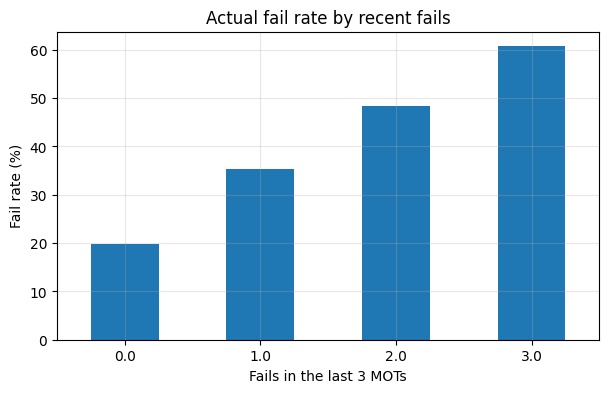

In [2]:
by = train.groupby("fails_last_3")["target_failed"].agg(fail_rate="mean", cars="size")
print(by.round(3))
ax = (by["fail_rate"] * 100).plot(kind="bar", rot=0, title="Actual fail rate by recent fails")
ax.set(xlabel="Fails in the last 3 MOTs", ylabel="Fail rate (%)"); plt.show()

## 2. One feature, fitted

Logistic regression fits just **two numbers** here: an intercept $b_0$ and a coefficient $b_1$. For a car with $x$ recent fails:

$$\text{score} = b_0 + b_1 x \qquad\qquad p = \frac{1}{1 + e^{-\text{score}}}$$

The score can be any number; the second formula, the **sigmoid**, squashes it into a probability between 0 and 1. The fitted curve should pass close to the actual fail rates from step 1.

b0 (intercept) = -1.346   b1 (per recent fail) = +0.644   odds x1.90 per fail


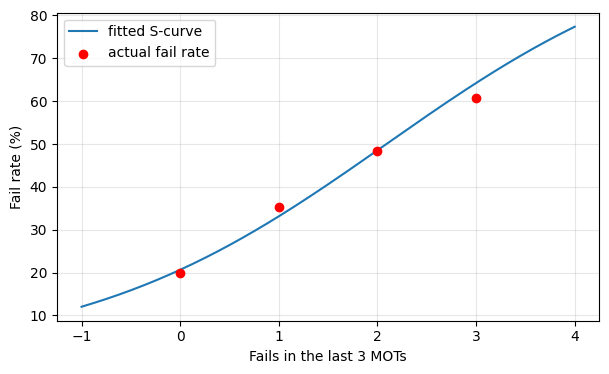

In [3]:
X1 = train[["fails_last_3"]].to_numpy()
m1 = LogisticRegression(C=1e6).fit(X1, y)          # C=1e6: effectively no penalty, a plain fit
b0, b1 = m1.intercept_[0], m1.coef_[0][0]
print(f"b0 (intercept) = {b0:+.3f}   b1 (per recent fail) = {b1:+.3f}   odds x{np.exp(b1):.2f} per fail")

xs = np.linspace(-1, 4, 200)
plt.plot(xs, 100 / (1 + np.exp(-(b0 + b1 * xs))), label="fitted S-curve")
plt.scatter(by.index, by["fail_rate"] * 100, color="red", zorder=3, label="actual fail rate")
plt.xlabel("Fails in the last 3 MOTs"); plt.ylabel("Fail rate (%)"); plt.legend(); plt.show()

**Try this:** set `x = 2` and compute `1 / (1 + np.exp(-(b0 + b1 * x)))` yourself. It should match the curve at 2, and the red dot's rate fairly closely.

## 3. Why it's a straight line in log-odds

The sigmoid curves, but underneath it the model is **linear**. Convert each group's actual fail rate into log-odds, $\ln\frac{p}{1-p}$, and they fall close to a straight line with intercept $b_0$ and slope $b_1$. That's all "logistic regression" means: a straight line, on the log-odds scale.

Each step along the line adds $b_1$ to the log-odds, which **multiplies the odds** by $e^{b_1}$, the odds ratio.

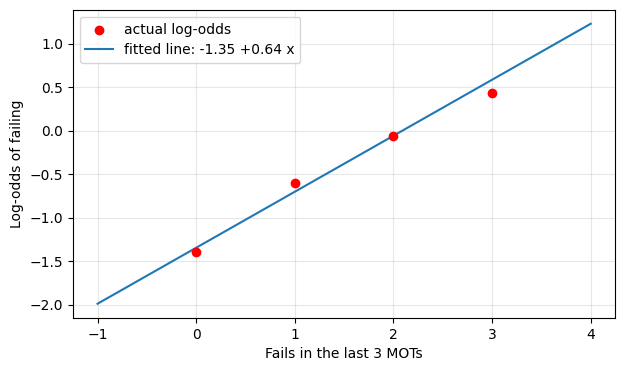

              actual rate   odds  odds / previous row
fails_last_3                                         
0.0                 0.198  0.248                  NaN
1.0                 0.353  0.546                2.205
2.0                 0.484  0.939                1.720
3.0                 0.607  1.544                1.645 
model's odds ratio per fail: 1.904


In [4]:
logodds = np.log(by["fail_rate"] / (1 - by["fail_rate"]))
plt.scatter(by.index, logodds, color="red", zorder=3, label="actual log-odds")
plt.plot(xs, b0 + b1 * xs, label=f"fitted line: {b0:+.2f} {b1:+.2f} x")
plt.xlabel("Fails in the last 3 MOTs"); plt.ylabel("Log-odds of failing"); plt.legend(); plt.show()

tbl = pd.DataFrame({"actual rate": by["fail_rate"], "odds": by["fail_rate"] / (1 - by["fail_rate"])})
tbl["odds / previous row"] = tbl["odds"] / tbl["odds"].shift()
print(tbl.round(3), f"\nmodel's odds ratio per fail: {np.exp(b1):.3f}")

## 4. Two features: "holding the others equal"

Cars with more recent fails also tend to be **older**, and older cars fail more anyway. So part of $b_1$ in step 2 was really age. Add age to the model, and $b_1$ now measures the effect of recent fails **for cars of the same age**.

In [5]:
X2 = train[["fails_last_3", "age_years"]].to_numpy()
m2 = LogisticRegression(C=1e6, max_iter=1000).fit(X2, y)
print(f"recent fails alone:      b1 = {b1:+.3f}  (odds x{np.exp(b1):.2f})")
print(f"recent fails, age equal: b1 = {m2.coef_[0][0]:+.3f}  (odds x{np.exp(m2.coef_[0][0]):.2f})")
print(f"age, per year:           b2 = {m2.coef_[0][1]:+.3f}  (odds x{np.exp(m2.coef_[0][1]):.2f})")
print(f"\naverage age by recent fails:\n{train.groupby('fails_last_3')['age_years'].mean().round(1)}")

recent fails alone:      b1 = +0.644  (odds x1.90)
recent fails, age equal: b1 = +0.529  (odds x1.70)
age, per year:           b2 = +0.051  (odds x1.05)

average age by recent fails:
fails_last_3
0.0     7.4
1.0    10.7
2.0    12.6
3.0    13.9
Name: age_years, dtype: float64


If $b_1$ shrinks once age is added, some of the "recent fails" effect was age in disguise. The full model does this with all eight features at once: every coefficient is the effect **with all the others held equal**.

## 5. The real model: one car by hand

The deployed model is the same idea with 29 columns: seven standardised numeric features, two missing-history flags, and 20 make columns. Pick one car, multiply each column by its coefficient, add them up with the intercept, apply the sigmoid, and compare with scikit-learn's answer.

**Try this:** change `row` to look at other cars.

In [6]:
row = 0
car = df.loc[[df.index[row]]]
x = design_matrix(car, model)[0]                         # the 29 numbers the model sees
coefs = np.array(model["coefficients"])

score = model["intercept"] + (x * coefs).sum()
p_by_hand = 1 / (1 + np.exp(-score))

sk = LogisticRegression()
sk.classes_, sk.coef_, sk.intercept_ = np.array([0, 1]), coefs.reshape(1, -1), np.array([model["intercept"]])
p_sklearn = sk.predict_proba(x.reshape(1, -1))[0, 1]

parts = pd.DataFrame({"value (scaled)": x, "coefficient": coefs, "contribution": x * coefs}, index=model["columns"])
print(parts[parts["value (scaled)"] != 0].round(3))
print(f"\nintercept {model['intercept']:+.3f} + contributions {(x * coefs).sum():+.3f} = score {score:+.3f}")
print(f"probability by hand {p_by_hand:.4f}   |   scikit-learn {p_sklearn:.4f}   (before calibration)")

                 value (scaled)  coefficient  contribution
age_years                -1.031        0.096        -0.099
n_prior_fails            -0.818        0.146        -0.120
fails_last_3             -0.830        0.235        -0.195
prev_odometer            -0.174        0.192        -0.033
prev_fail_items          -0.454        0.100        -0.045
prev_advisories          -0.651        0.137        -0.089
days_since_prev          -0.105        0.051        -0.005
no_history                1.000       -0.462        -0.462

intercept -0.950 + contributions -1.049 = score -1.999
probability by hand 0.1193   |   scikit-learn 0.1193   (before calibration)


The two probabilities match: there's nothing more to the model than this sum and the sigmoid. The site then applies one last step, **Platt calibration**, which adjusts the score to $a \times \text{score} + b$ before the sigmoid, to correct for fail rates drifting since training.